# Load packages

Read in all necessary packages:

In [10]:
from IPython.display import display, HTML
display(HTML("<style>.container { width:90% !important; }</style>"))
%matplotlib inline

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import scanpy as sc
import numpy as np
import decoupler as dc


In [2]:
# Import DESeq2
from pydeseq2.dds import DeseqDataSet, DefaultInference
from pydeseq2.ds import DeseqStats

In [3]:
import decoupler as dc

In [4]:
sc.set_figure_params(dpi = 80)
sns.set_style("white")
sns.set_context("talk")
sns.set_style("ticks")

# Load the dataset

## load adata file and define groups for differential expression

In [5]:
adata = sc.read_h5ad('../../../tchic_local/fig6_build/legacy/data/20230704_adata_all.h5ad')
adata

AnnData object with n_obs × n_vars = 38117 × 27384
    obs: 'batch', 'day', 'replicates', 'mark', 'day_rep', 'dataset', 'hour', 'celltype', 'celltype_general', 'lineage', 'lin_day', 'percent_mito', 'n_counts', 'n_counts_proteincoding', 'n_genes', 'S_score', 'G2M_score', 'phase', 'enrichment', 'coverage', 'QC', 'pseudotime', 'pseudotime2'
    var: 'Accession', 'Chromosome', 'End', 'Start', 'Strand', 'gene', 'gene_biotype', 'gene_counts', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
    uns: 'QC_colors', 'batch_colors', 'celltype_colors', 'celltype_general_colors', 'dataset_colors', 'day_colors', 'hour_colors', 'hvg', 'leiden', 'leiden_colors', 'lin_day_colors', 'lineage_colors', 'log1p', 'mark_colors', 'neighbors', 'old_celltype_colors', 'old_leiden_general_colors', 'old_leiden_merge_colors', 'pca', 'phase_colors', 'predicted_final_colors', 'predicted_id_E75_colors', 'predicted_id_E85_colors', 'replicates_colors', 'umap', 'umap_density_mark_par

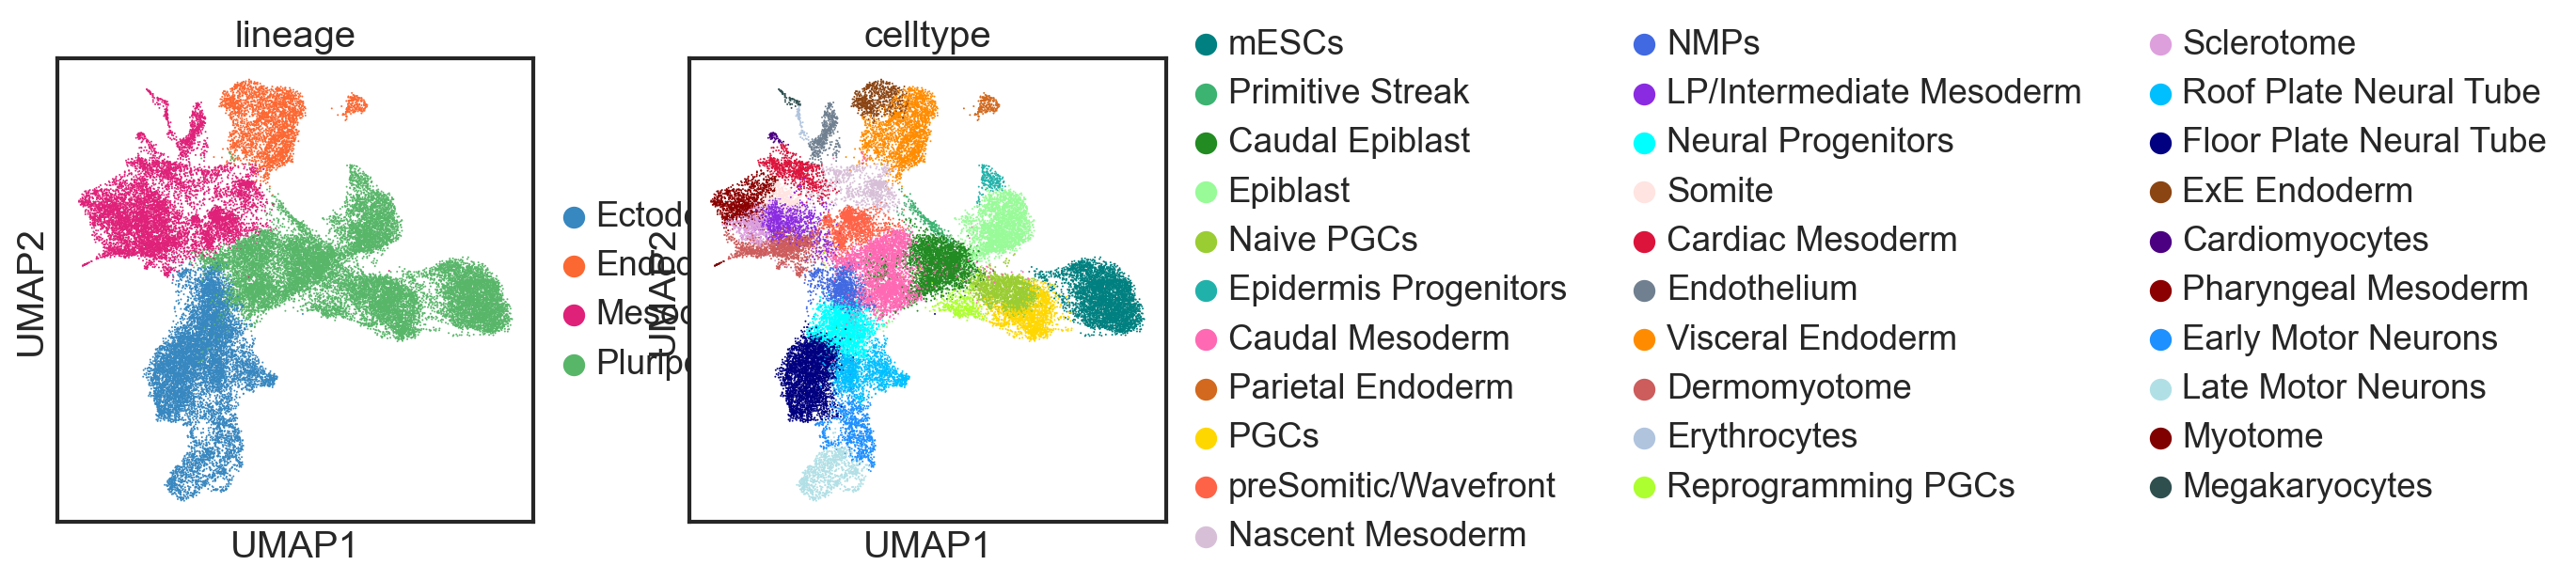

In [6]:
sc.pl.umap(adata, color = ['lineage', 'celltype'])

In [13]:
import_trajectories = pd.read_csv('../dfs/20250304_trajectories.csv', index_col = 0)
adata.obs['trajectories'] = import_trajectories['trajectories']

In [14]:
pal = ['#6AAED6', '#3787C0', '#105BA4', '#D6E6F4',
      '#FC6832',
      '#DF64AF', '#DF2179', '#A90649',
      '#E1D4E8','#CDA0CD',
      '#2C8F4B','#97D385', 'lightgrey']

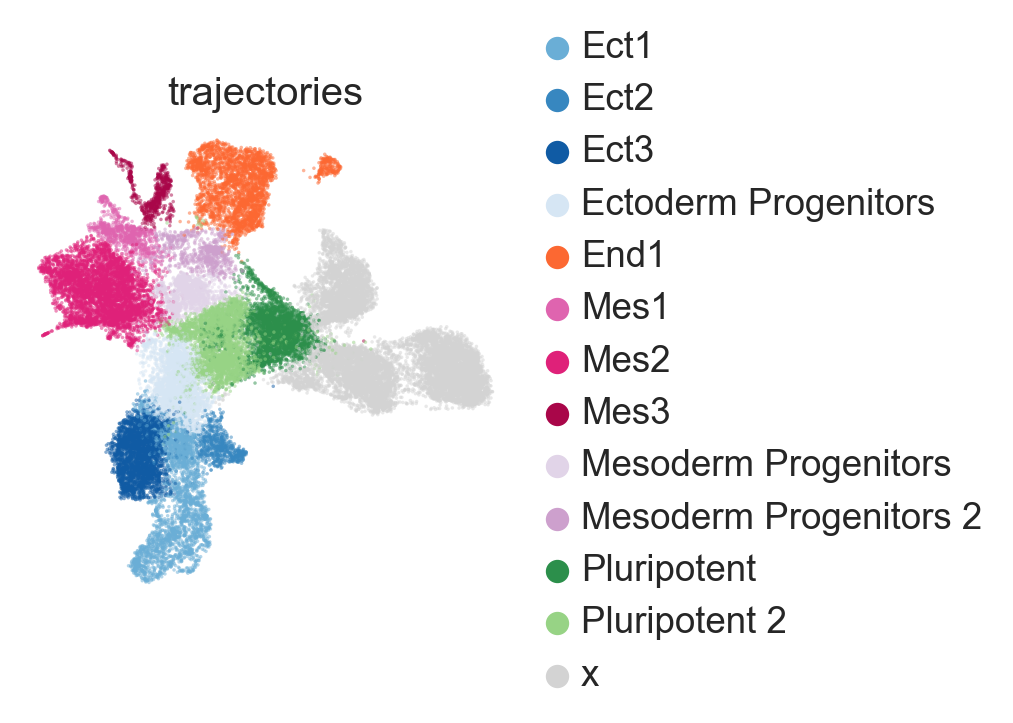

In [15]:
sc.pl.umap(adata, color = 'trajectories', palette = pal, size = 10, alpha = 0.5, frameon = False)

In [21]:
groups = 'trajectories'

/Users/mbloten1/miniconda3/envs/conda_base/lib/python3.10/site-packages/scanpy/plotting/_utils.py:487: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[value_to_plot + "_colors"] = colors_list


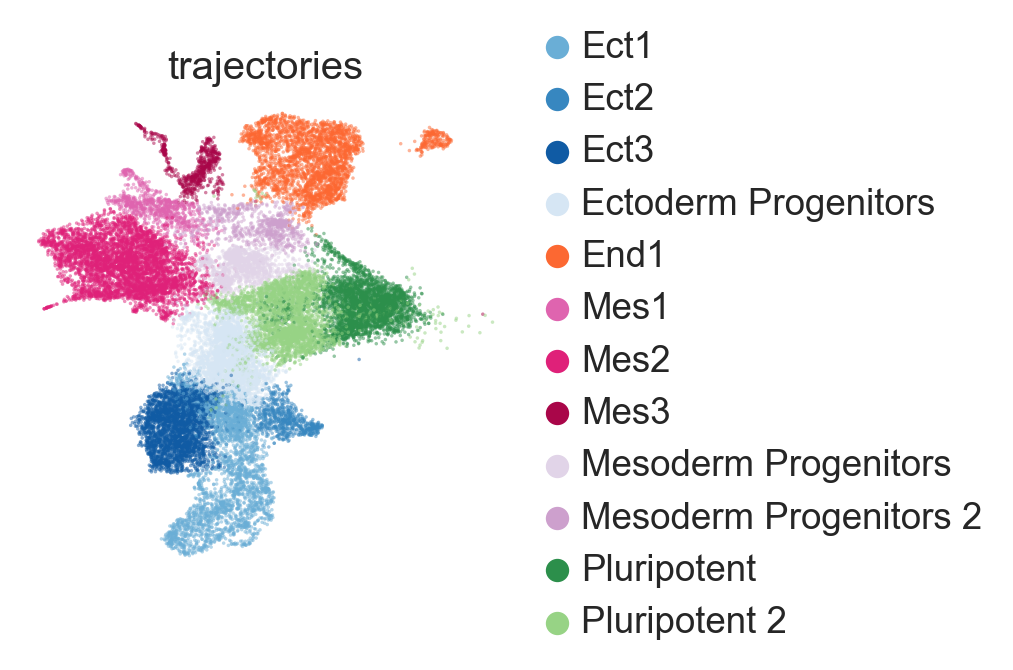

In [19]:
# only keep cells annotated in diffx
adata_f = adata[adata.obs[groups] != 'x']
sc.pl.umap(adata_f, color = groups, palette = pal, size = 10, alpha = 0.5, frameon = False)

In [20]:
sc.settings.verbosity = 2

# do standard scanpy diff gene analysis

In [22]:
sc.tl.rank_genes_groups(adata_f, groupby = groups,method='wilcoxon')

ranking genes
    finished (0:00:39)


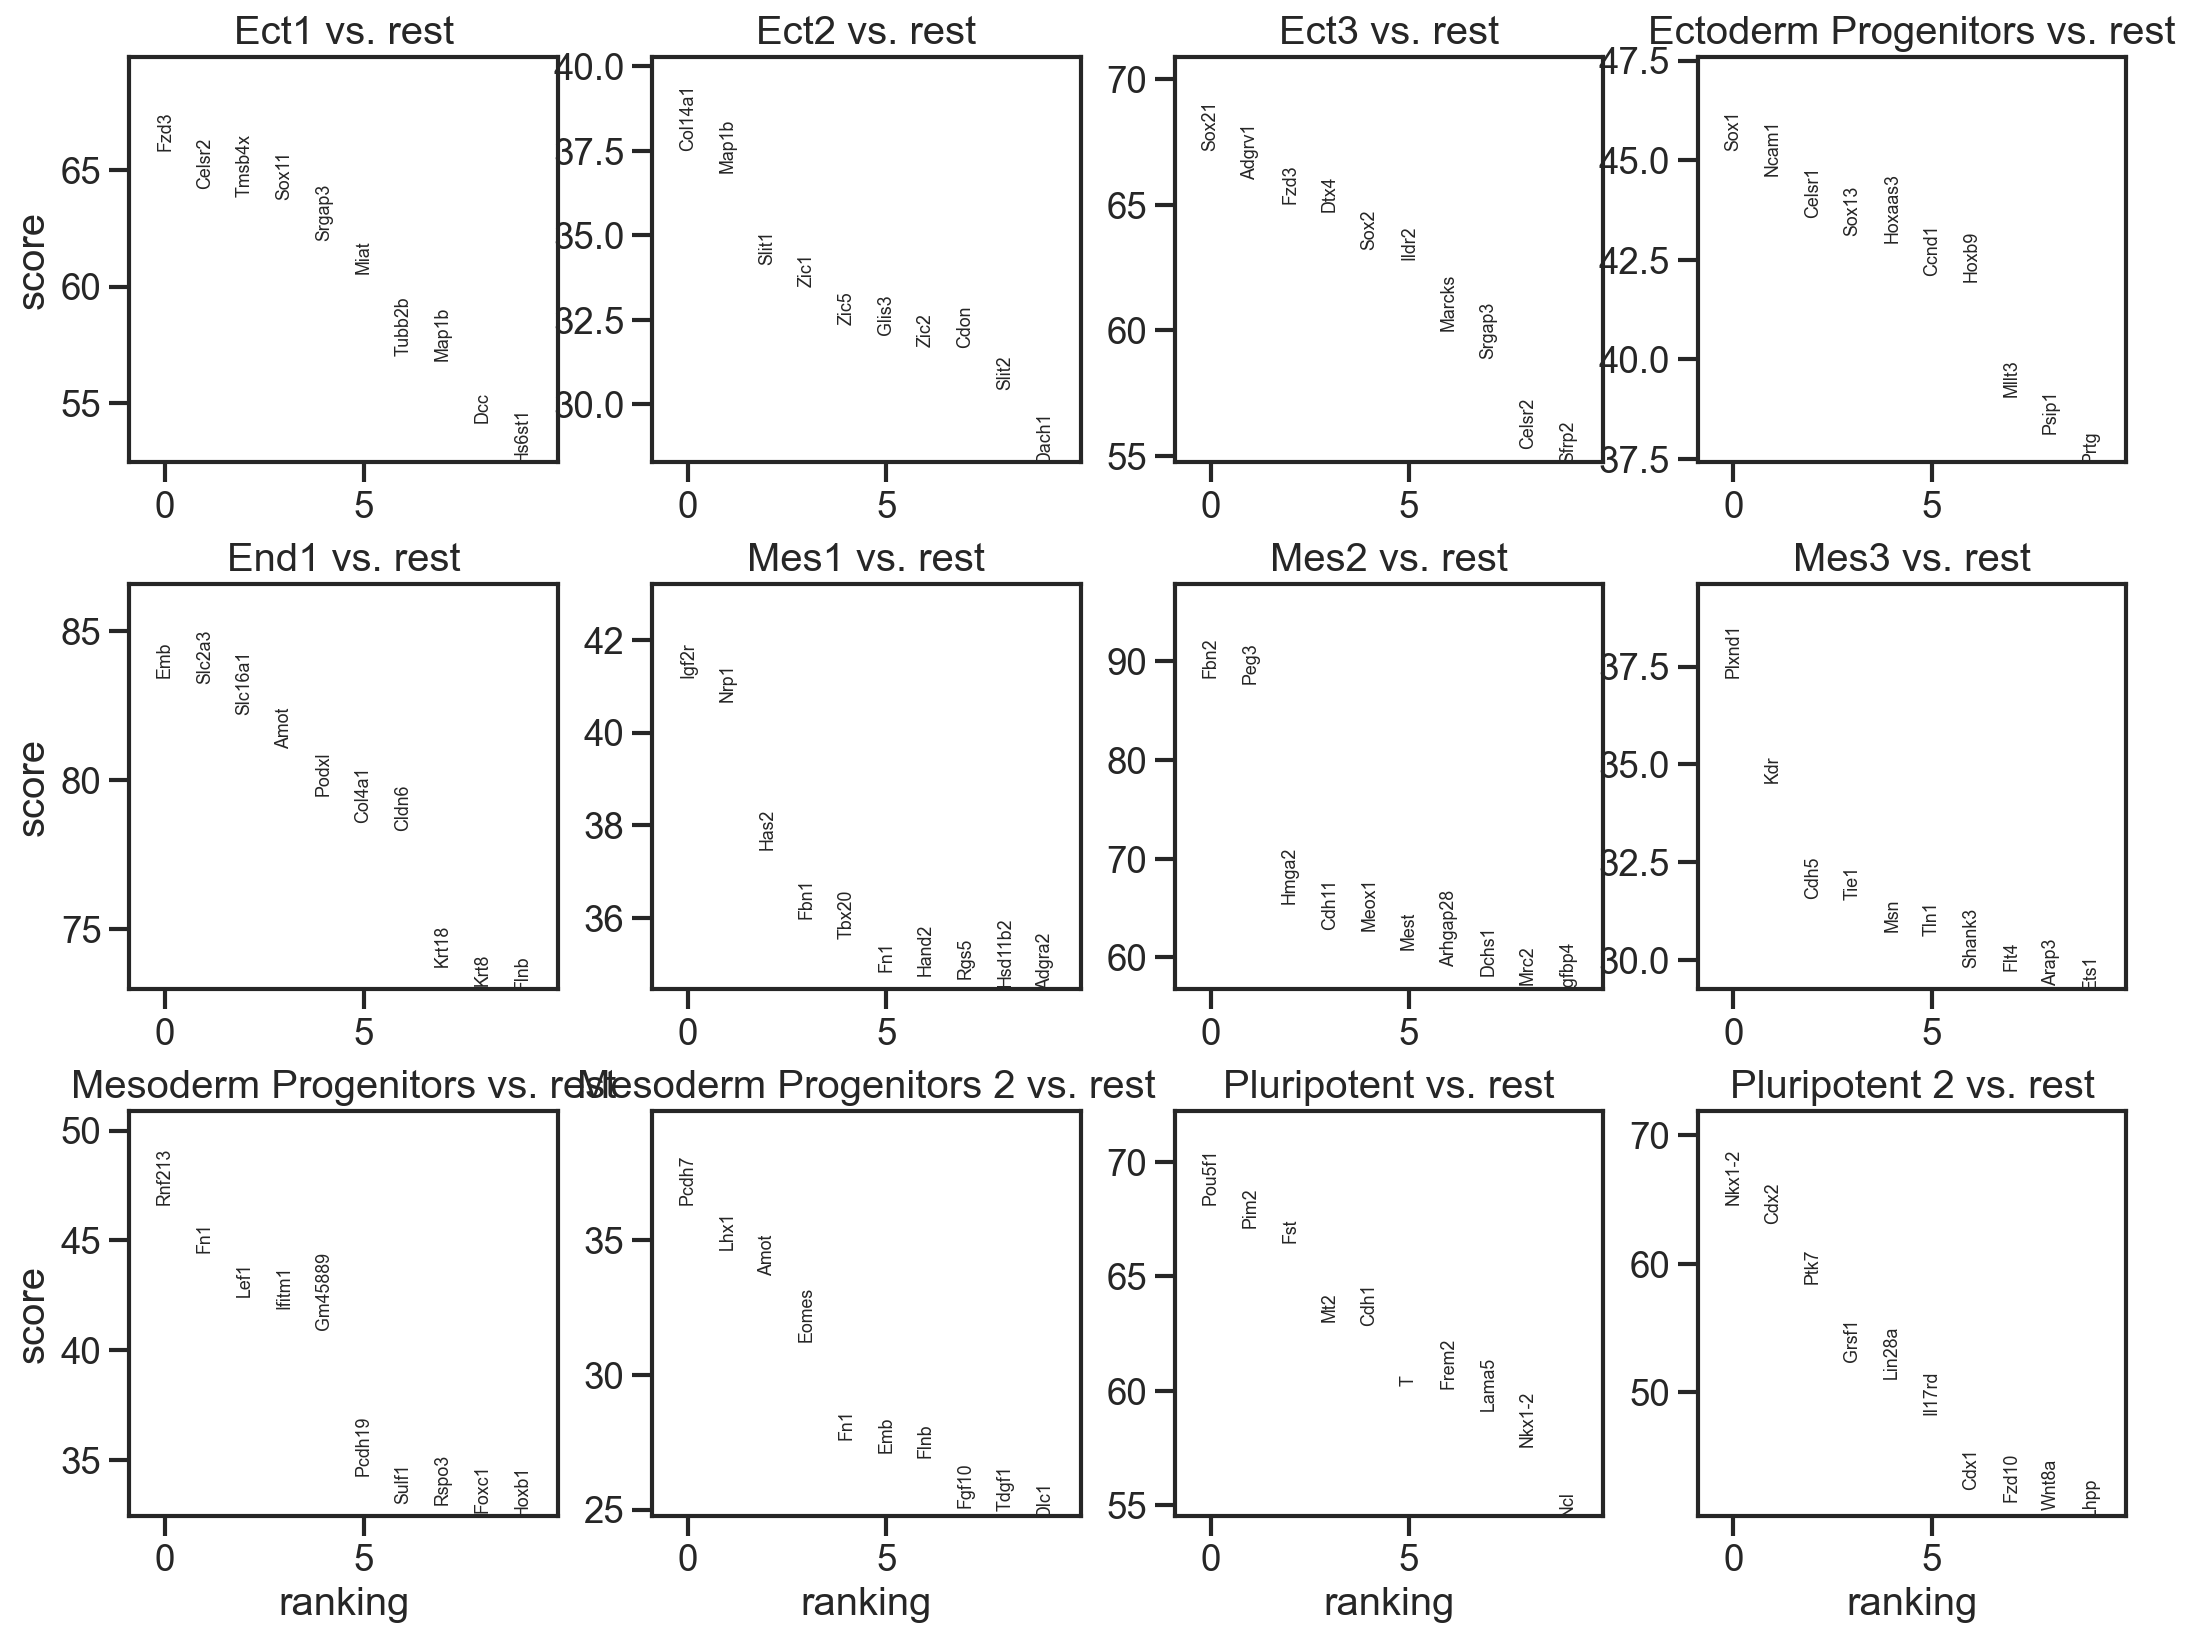

In [23]:
sc.pl.rank_genes_groups(adata_f, n_genes=10, sharey=False)


    using 'X_pca' with n_pcs = 50
Storing dendrogram info using `.uns['dendrogram_trajectories']`


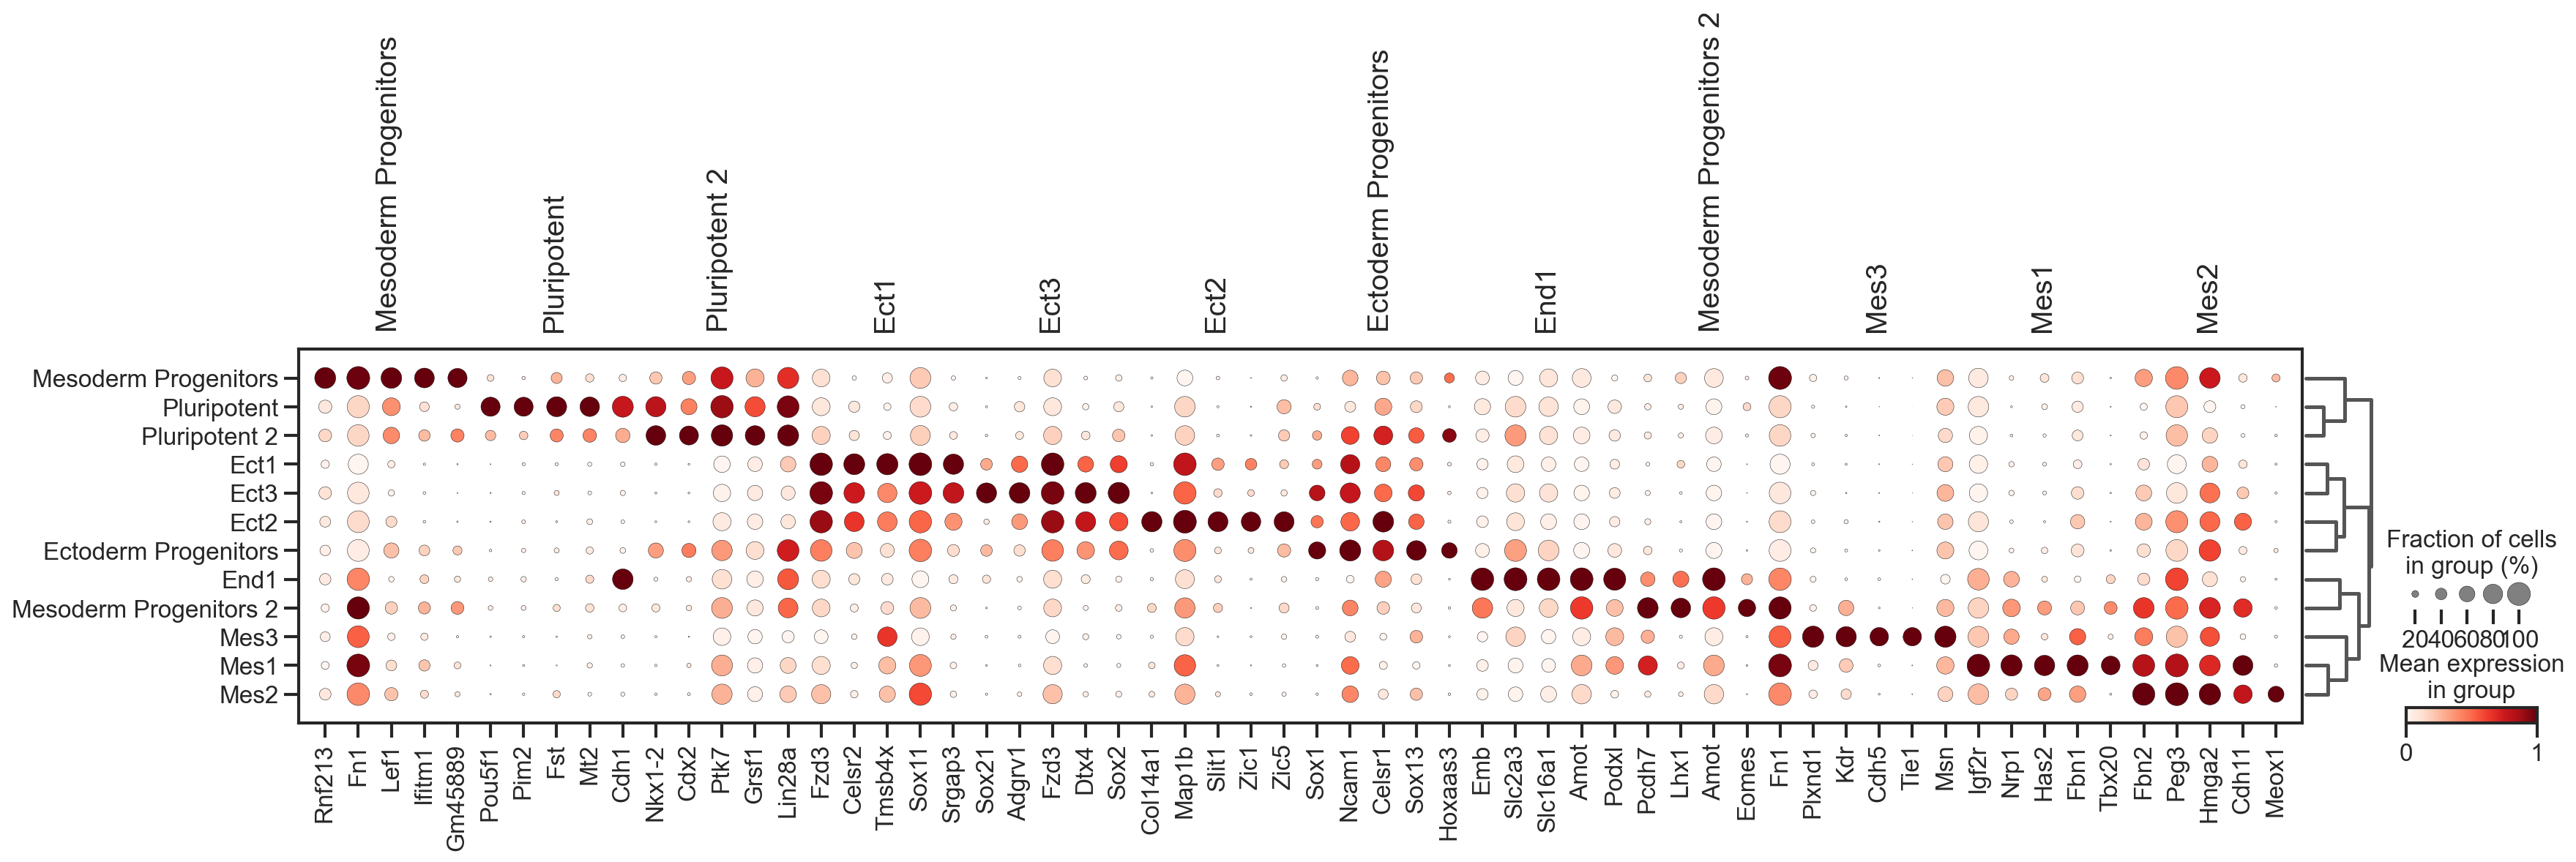

In [24]:
sc.pl.rank_genes_groups_dotplot(
    adata_f, groupby=groups, standard_scale="var", n_genes=5
)
plt.show()

In [29]:
def get_diff_exp(name):
    diff_exp = sc.get.rank_genes_groups_df(adata_f, group = name)
    diff_exp.index = diff_exp['names']
    diff_exp = diff_exp.rename(columns = {'logfoldchanges':'log2FoldChange', 'pvals_adj': 'padj','scores':'stat'})
    diff_exp['p_log10'] = -np.log10(diff_exp['padj'])
    scanpy_up = diff_exp[(diff_exp['log2FoldChange'] > 2) & (diff_exp['padj'] < 0.05)]
    return diff_exp, scanpy_up


In [37]:
mes1_df, mes1_up = get_diff_exp('Mes1')
mes2_df, mes2_up = get_diff_exp('Mes2')
mes3_df, mes3_up = get_diff_exp('Mes3')

ect1_df, ect1_up = get_diff_exp('Ect1')
ect2_df, ect2_up = get_diff_exp('Ect2')
ect3_df, ect3_up = get_diff_exp('Ect3')

/Users/mbloten1/miniconda3/envs/conda_base/lib/python3.10/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/Users/mbloten1/miniconda3/envs/conda_base/lib/python3.10/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/Users/mbloten1/miniconda3/envs/conda_base/lib/python3.10/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/Users/mbloten1/miniconda3/envs/conda_base/lib/python3.10/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [32]:
ct_cols = dict(zip(adata.obs['trajectories'].cat.categories, adata.uns['trajectories_colors']))

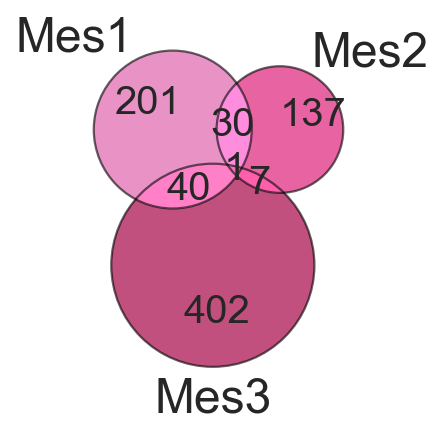

In [36]:
from matplotlib_venn import venn3, venn3_circles

ct = ['Mes1','Mes2','Mes3']

A = mes1_up.index
B = mes2_up.index
C = mes3_up.index

fig,ax = plt.subplots(figsize = (3,3))
venn3([set(A),set(B),set(C)],ax=ax, set_colors = [ct_cols[ct[0]], ct_cols[ct[1]], ct_cols[ct[2]]],set_labels = ct,
      alpha = 0.7)
c = venn3_circles([set(A),set(B),set(C)],color = 'black',linewidth = 1,ax=ax, 
      alpha = 0.6)

#plt.savefig('figs/venn3_neg.png',bbox_inches='tight')
plt.show()

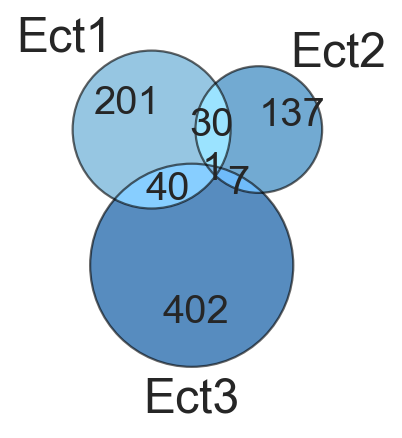

In [38]:
from matplotlib_venn import venn3, venn3_circles

ct = ['Ect1','Ect2','Ect3']

A = mes1_up.index
B = mes2_up.index
C = mes3_up.index

fig,ax = plt.subplots(figsize = (3,3))
venn3([set(A),set(B),set(C)],ax=ax, set_colors = [ct_cols[ct[0]], ct_cols[ct[1]], ct_cols[ct[2]]],set_labels = ct,
      alpha = 0.7)
c = venn3_circles([set(A),set(B),set(C)],color = 'black',linewidth = 1,ax=ax, 
      alpha = 0.6)

#plt.savefig('figs/venn3_neg.png',bbox_inches='tight')
plt.show()

In [41]:
mes1_up.to_csv('dfs/20250403_mes1_diffexp.csv')
mes2_up.to_csv('dfs/20250403_mes2_diffexp.csv')
mes3_up.to_csv('dfs/20250403_mes3_diffexp.csv')

ect1_up.to_csv('dfs/20250403_ect1_diffexp.csv')
ect2_up.to_csv('dfs/20250403_ect2_diffexp.csv')
ect3_up.to_csv('dfs/20250403_ect3_diffexp.csv')

In [ ]:
count_table = pd.read_csv('../../../tchic_local/fig6_build/20250215_count_data_all_thresh.tsv', index_col = 0, header = 0, low_memory= False, sep = '\t')

# old

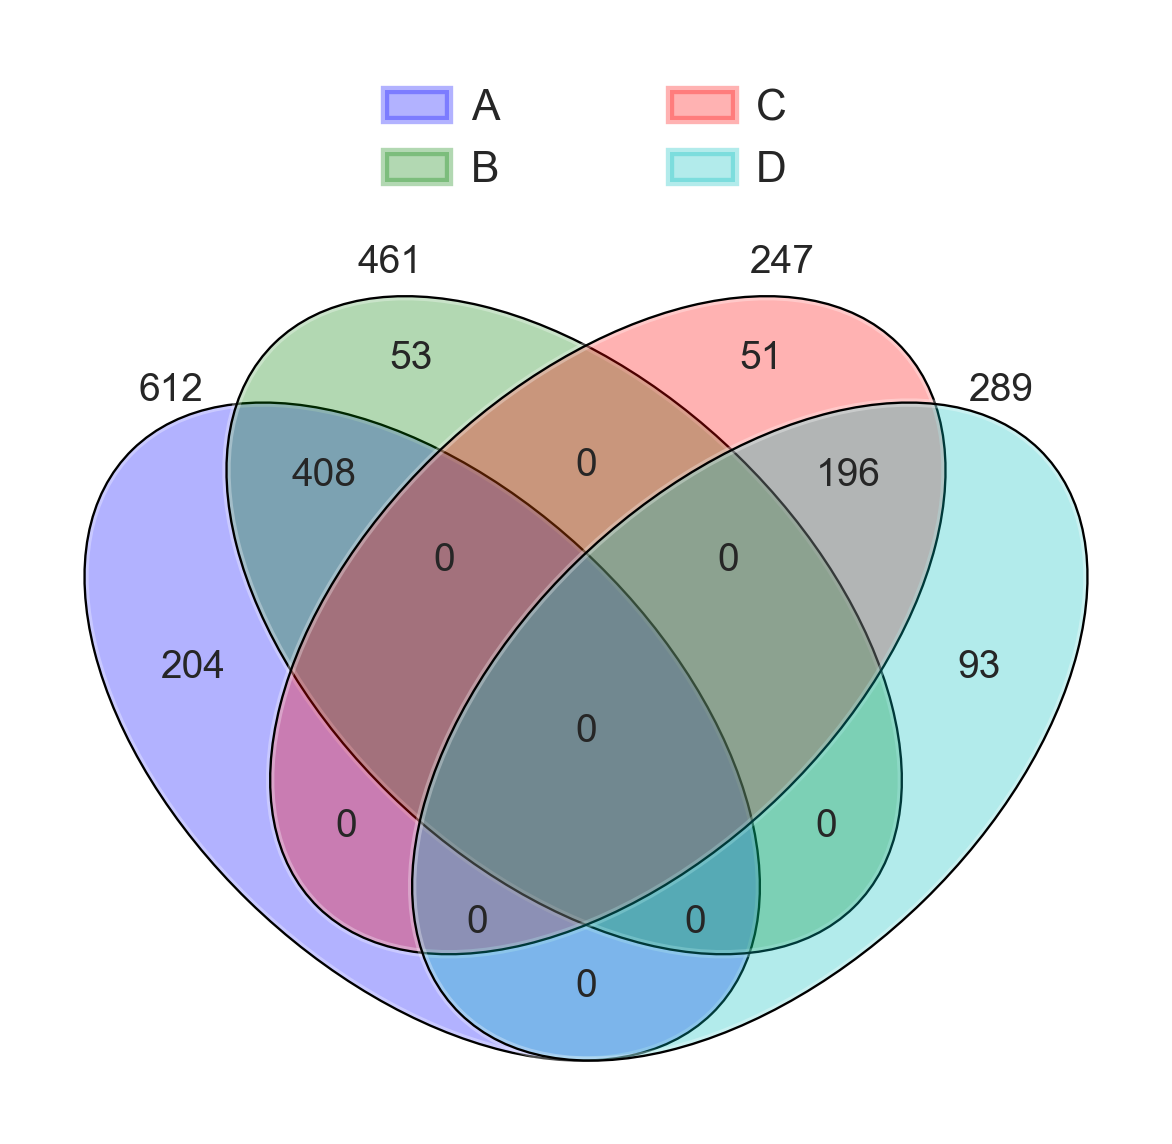

In [53]:
from venny4py.venny4py import *

#dict of sets
sets = {
    'A': set(list(up.index)),
    'B': set(list(scanpy_up['names'])),
    'C': set(list(down.index)),
    'D': set(list(scanpy_down['names']))}
    
venny4py(sets=sets, )#colors = list(lin_colors.values()),)

#plt.savefig('figs/venn4.png',bbox_inches='tight')
plt.show()

In [54]:
sc.set_figure_params(dpi = 80)

sns.set_style("white")
sns.set_context("talk")
sns.set_style("ticks")

In [55]:
cols[0]

'#df2179'

# all plots for diff expressed genes

In [58]:
def makeVolcano(df, df_up, df_down, lfc = 'log2FoldChange'):
    fig,ax = plt.subplots(figsize = (4,4))
    
    sns.scatterplot(data = df,
                   x = lfc,s=12,edgecolor = None,
                   y = 'p_log10',alpha = 0.4,
                   c = 'grey')
    
    sns.scatterplot(data = df_up,
                   x = lfc,s=12,edgecolor = None,
                   y = 'p_log10',
                   c = cols[0] )
    
    sns.scatterplot(data = df_down,
                   x = lfc,s=12,edgecolor = None,
                   y = 'p_log10',
                   c = cols[1] )
    ax.legend([],frameon=False)
    ax.set_ylabel('log10 [p-value]')
    ax.set_xlabel('log2 FC')
    
    
    #plt.savefig('figs/volcanoes_diffexpressed.png', bbox_inches='tight')
    plt.show()

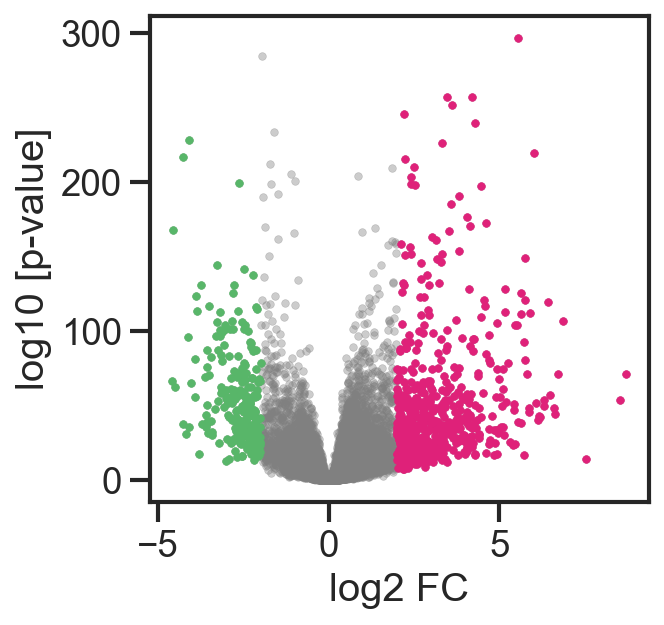

In [59]:
makeVolcano(results_df,up,down)

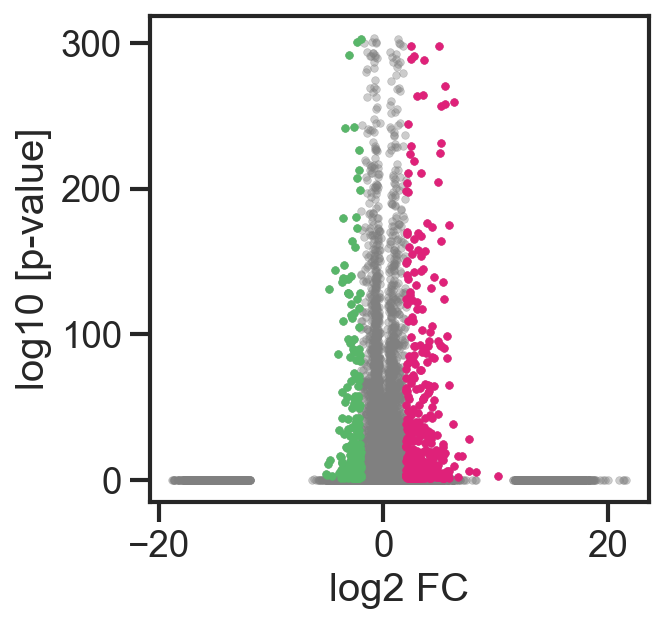

In [60]:
makeVolcano(diff_exp,scanpy_up,scanpy_down)

In [61]:
allgenes = list(results_df.index.unique())
def plotGO(genelist, reflist, n = 10, save = None, source = 'GO:BP'):
    plotcl = sc.queries.enrich({'cluster':genelist,
                   'all':reflist}, org="mmusculus")
    cluster = 'cluster'
    plot1 = plotcl[plotcl['query'] == cluster][plotcl[plotcl['query'] == cluster]['source'] == source].sort_values(by='p_value')[['name','p_value']][0:n]
    plot1['-log (p-value)'] = np.log10(plot1['p_value'])*-1
    sns.set_style('ticks')
    sns.set_context('talk')
    fig,ax = plt.subplots(figsize = (6,3))
    ax = sns.barplot(y=plot1['name'],x=plot1['-log (p-value)'], ax=ax,color = 'grey')
    ax.set_ylabel('')
    if save != None:
        plt.savefig(save , bbox_inches='tight')
    #sns.despine()
    plt.show()

In [62]:
len(list(up.index))

612

In [63]:
len(list(down.index))

247

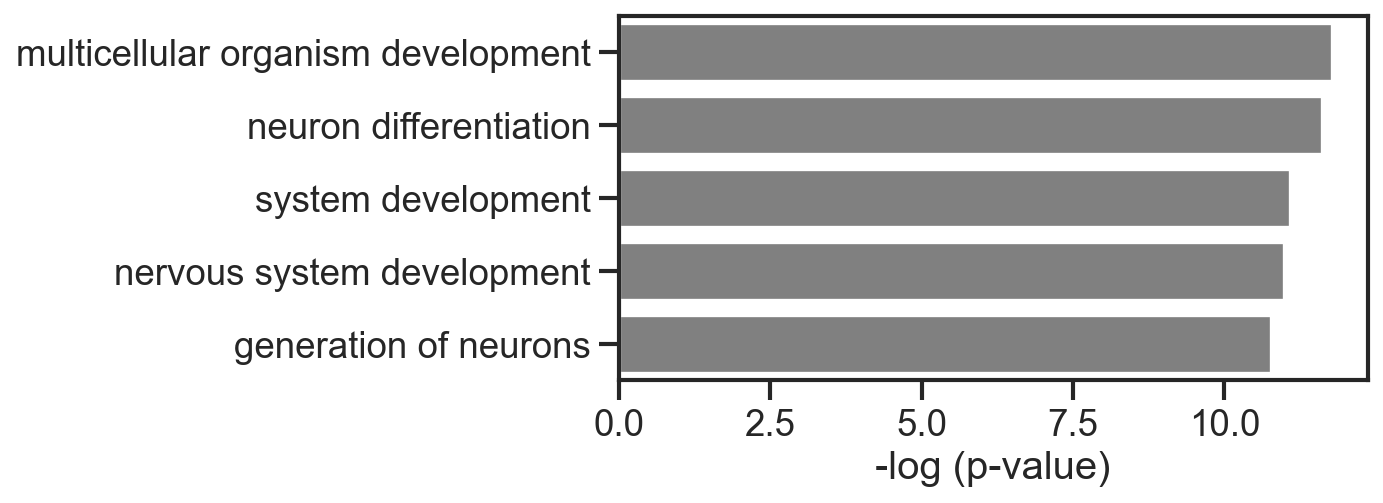

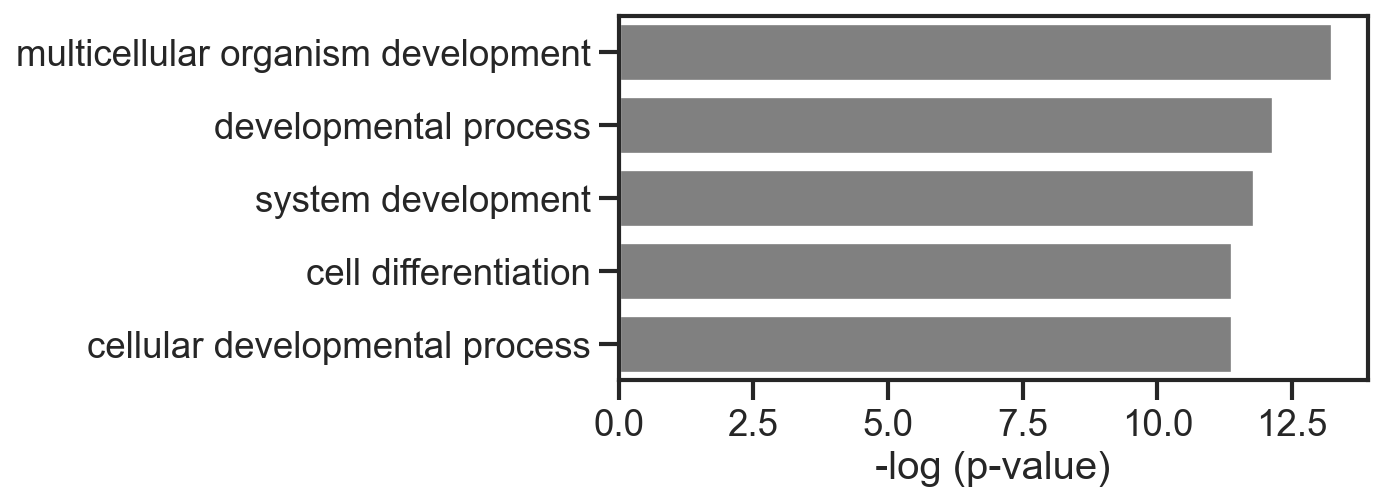

In [65]:
plotGO(list(down.index),allgenes, n = 5)
plotGO(list(scanpy_down['names']),allgenes, n = 5)